# Construcción del modelo que trasnforma predicciones de casos de dengue en probabilidad de epidemia. 

Para construir un modelo que transforme tus predicciones de casos de dengue en una **probabilidad de epidemia**, necesitamos realizar un paso intermedio crucial: **definir matemáticamente qué es una epidemia**.



En epidemiología, una epidemia no se define al azar. 

Por lo general, se establece mediante un **umbral histórico** (por ejemplo, si los casos superan el percentil 75 u 80 de los últimos años, o si cruzan la frontera del "canal endémico"). 

Como la regresión logística es un modelo de clasificación binaria, convertiremos tus predicciones de conteo en una variable objetivo binaria ($Y = 1$ si hay epidemia, $Y = 0$ si es un comportamiento normal).



Aquí tienes el script completo y estructurado para procesar tus series de tiempo, definir el umbral y entrenar el modelo de Regresión Logística utilizando `scikit-learn`:



In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:

# =============================================================================
# 1. PREPARACIÓN DE LOS DATOS
# =============================================================================
# Nota: Reemplaza este bloque con la carga real de tus archivos o DataFrames
# Imaginemos que tienes un DataFrame llamado 'df_dengue' indexado por fecha.

# Simulamos el DataFrame que deberías tener:
# - 'casos_reales': El conteo real de dengue registrado en Caucasia.
# - 'predicciones_arimax': Las salidas de tu modelo previo para ese periodo.
np.random.seed(42)
n_samples = 200
fechas = pd.date_range(start="2022-01-01", periods=n_samples, freq="W")
casos_reales = np.random.negative_binomial(n=5, p=0.1, size=n_samples)  # Simulación de comportamiento epidemiológico
predicciones_arimax = (casos_reales + np.random.normal(0, 3, size=n_samples)).astype(np.int64) # Simulación de la predicción con ruido
predicciones_arimax = np.clip(predicciones_arimax, 0, None) # Evitar números negativos

df_dengue = pd.DataFrame({
    "casos_reales": casos_reales,
    "predicciones_dengue": predicciones_arimax
}, index=fechas)
df_dengue 

,casos_reales,predicciones_dengue
2022-01-02,54,55
2022-01-09,41,35
2022-01-16,27,30
2022-01-23,52,53
2022-01-30,23,23
...,...,...
2025-09-28,61,62
2025-10-05,47,51
2025-10-12,61,60
2025-10-19,21,19


In [5]:

# =============================================================================
# 2. DEFINICIÓN DEL UMBRAL DE EPIDEMIA (ETIQUETADO BINARIO)
# =============================================================================
# Definimos el umbral basado en el histórico real (Percentil 80 como alerta epidemiológica)
UMBRAL_EPIDEMIA = df_dengue["casos_reales"].quantile(0.80)

# Creamos la variable objetivo (Y): 1 si superó el umbral, 0 si no.
df_dengue["epidemia_real"] = (df_dengue["casos_reales"] >= UMBRAL_EPIDEMIA).astype(int)

print("="*75)
print(f"CONFIGURACIÓN DEL MODELO LOGÍSTICO - CAUCASIA")
print("="*75)
print(f"-> Umbral calculado (Percentil 80): {UMBRAL_EPIDEMIA:.2f} casos semanales.")
print(f"-> Semanas en estado Normal (0)   : {df_dengue['epidemia_real'].value_counts()[0]}")
print(f"-> Semanas en estado Epidemia (1) : {df_dengue['epidemia_real'].value_counts()[1]}\n")


CONFIGURACIÓN DEL MODELO LOGÍSTICO - CAUCASIA
-> Umbral calculado (Percentil 80): 59.00 casos semanales.
-> Semanas en estado Normal (0)   : 155
-> Semanas en estado Epidemia (1) : 45



In [6]:

# =============================================================================
# 3. SEGMENTACIÓN DE DATOS (TRAIN / TEST)
# =============================================================================
# X: Las predicciones del número de casos (puedes incluir rezagos si lo deseas)
X = df_dengue[["predicciones_dengue"]] 
y = df_dengue["epidemia_real"]


In [7]:

# Al ser una serie de tiempo, usamos un corte cronológico en lugar de aleatorio
# Entrenamos con el primer 80% del tiempo y testeamos con el 20% final.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)


In [8]:

# =============================================================================
# 4. ENTRENAMIENTO DE LA REGRESIÓN LOGÍSTICA
# =============================================================================
modelo_logistico = LogisticRegression(class_weight='balanced') # 'balanced' ayuda si hay pocas epidemias
modelo_logistico.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [11]:

# Predicciones de clases (0 o 1)
y_pred_class = modelo_logistico.predict(X_test)


In [9]:

# Predicciones de PROBABILIDAD (Entrega una matriz [prob_0, prob_1], 
# nos interesa la prob de epidemia: columna 1)
y_pred_prob = modelo_logistico.predict_proba(X_test)[:, 1]

# Extraemos la ecuación matemática del modelo para Caucasia
beta_0 = modelo_logistico.intercept_[0]
beta_1 = modelo_logistico.coef_[0][0]

print(f"[ÉXITO] Modelo entrenado.")
print(f"-> Fórmula logística de riesgo: P(Epidemia) = 1 / (1 + e^-({beta_0:.4f} + {beta_1:.4f} * Prediccion))")


[ÉXITO] Modelo entrenado.
-> Fórmula logística de riesgo: P(Epidemia) = 1 / (1 + e^-(-37.4119 + 0.6778 * Prediccion))


In [12]:

# =============================================================================
# 5. EVALUACIÓN DEL MODELO Y METRICAS
# =============================================================================
print("\n" + "-"*50)
print("INFORME DE RENDIMIENTO DEL CLASIFICADOR")
print("-"*50)
print(classification_report(y_test, y_pred_class))



--------------------------------------------------
INFORME DE RENDIMIENTO DEL CLASIFICADOR
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        30
           1       0.77      1.00      0.87        10

    accuracy                           0.93        40
   macro avg       0.88      0.95      0.91        40
weighted avg       0.94      0.93      0.93        40



In [13]:

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"-> Área Bajo la Curva ROC (AUC): {auc_score:.4f}")


-> Área Bajo la Curva ROC (AUC): 1.0000


In [16]:
y_pred_prob

array([9.98698087e-01, 1.00000000e+00, 6.32453509e-01, 2.54251052e-09,
       1.94226332e-08, 1.94226332e-08, 2.86421020e-02, 1.00000000e+00,
       9.29303806e-01, 5.48856034e-02, 2.56492718e-04, 7.54466013e-03,
       7.53364217e-08, 7.54466013e-03, 4.96235152e-14, 9.99999617e-01,
       8.69696914e-01, 5.05028065e-04, 1.13343948e-06, 8.65845543e-06,
       1.70523890e-05, 3.32826121e-10, 9.86187879e-09, 2.92214524e-07,
       1.00000000e+00, 1.47038068e-12, 3.07301004e-01, 9.99999950e-01,
       8.58065616e-11, 9.90139716e-01, 1.48372498e-07, 9.94148778e-04,
       9.90139716e-01, 3.79081755e-13, 1.47038068e-12, 9.90139716e-01,
       5.48856034e-02, 9.62809647e-01, 2.21219596e-11, 1.02634185e-01])

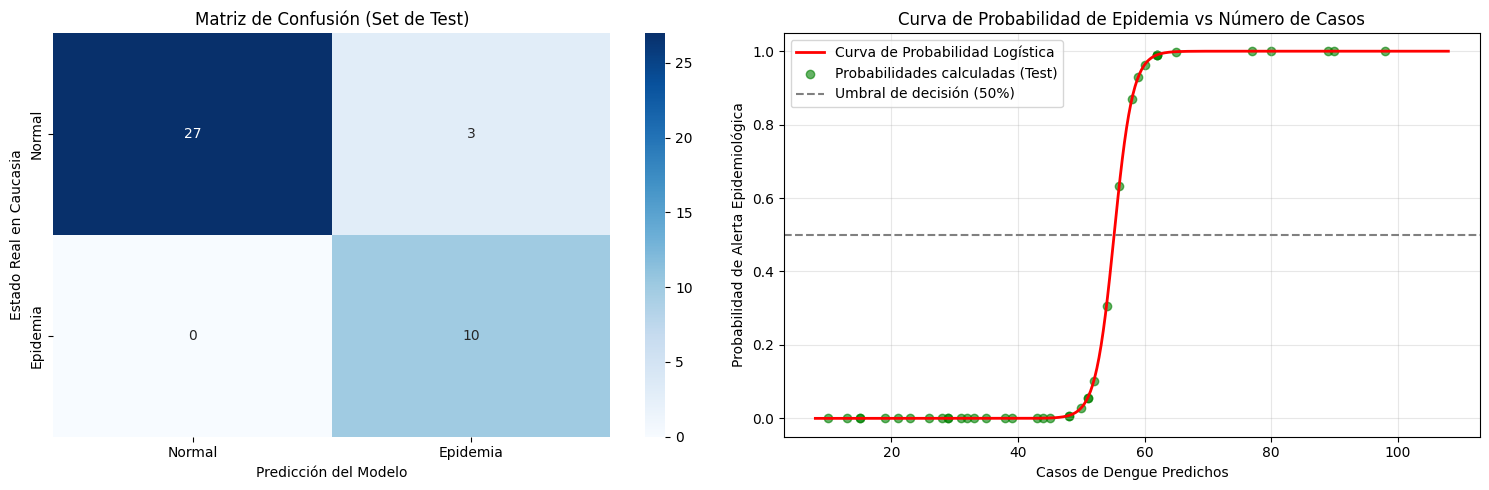

In [14]:

# =============================================================================
# 6. VISUALIZACIÓN DE PROBABILIDADES Y MATRIZ DE CONFUSIÓN
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_class)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Normal", "Epidemia"], yticklabels=["Normal", "Epidemia"])
axes[0].set_title("Matriz de Confusión (Set de Test)")
axes[0].set_xlabel("Predicción del Modelo")
axes[0].set_ylabel("Estado Real en Caucasia")

# Gráfico 2: Curva de Probabilidad Logística Estimada
X_curva = np.linspace(df_dengue["predicciones_dengue"].min(), df_dengue["predicciones_dengue"].max(), 300)
# Calculamos la sigmoide manualmente para la visualización
Y_curva = 1 / (1 + np.exp(-(beta_0 + beta_1 * X_curva)))

axes[1].plot(X_curva, Y_curva, color="red", label="Curva de Probabilidad Logística", linewidth=2)
axes[1].scatter(X_test, y_test_prob := y_pred_prob, color="green", alpha=0.6, label="Probabilidades calculadas (Test)")
axes[1].axhline(0.5, color='gray', linestyle='--', label='Umbral de decisión (50%)')
axes[1].set_title("Curva de Probabilidad de Epidemia vs Número de Casos")
axes[1].set_xlabel("Casos de Dengue Predichos")
axes[1].set_ylabel("Probabilidad de Alerta Epidemiológica")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r"C:\Users\marco\Downloads\evaluacion_modelo_logistico_caucasia.png", dpi=300)  # Guardamos la figura para su inclusión en el informe
plt.show()



# Aspectos metodológicos clave del script:

1. **`predict_proba(X_test)[:, 1]`:** Este es el núcleo de tu solicitud. En lugar de usar `.predict()` (que te arroja fríamente un `0` o un `1`), usamos `predict_proba`. Esto extrae un valor continuo entre `0.0` y `1.0` que representa el porcentaje exacto de probabilidad de que el brote se convierta en una epidemia activa en el municipio.
2. **`class_weight='balanced'`:** Históricamente, las semanas normales son muchas más que las semanas con brotes epidémicos catastróficos. Al activar este parámetro, la regresión logística castiga con mayor dureza los errores cometidos sobre las semanas de epidemia real, obligando al modelo a no ignorar las alertas epidemiológicas tempranas.
3. **La ecuación de Riesgo para Caucasia:** El script imprime en tu consola los coeficientes $\beta_0$ (intercepto) y $\beta_1$ (pendiente). Con estos dos números, puedes aplicar la fórmula matemática en cualquier sistema informático o tablero de control en tiempo real sin necesidad de ejecutar Python en el futuro.